<a href="https://colab.research.google.com/github/Nilamsari01/Pengolahan_Citra_Digital/blob/main/Tugas4_Nilam%20Sari__F1G124046.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gambar berhasil dibaca.
Ukuran gambar:
Tinggi : 636
Lebar  : 450


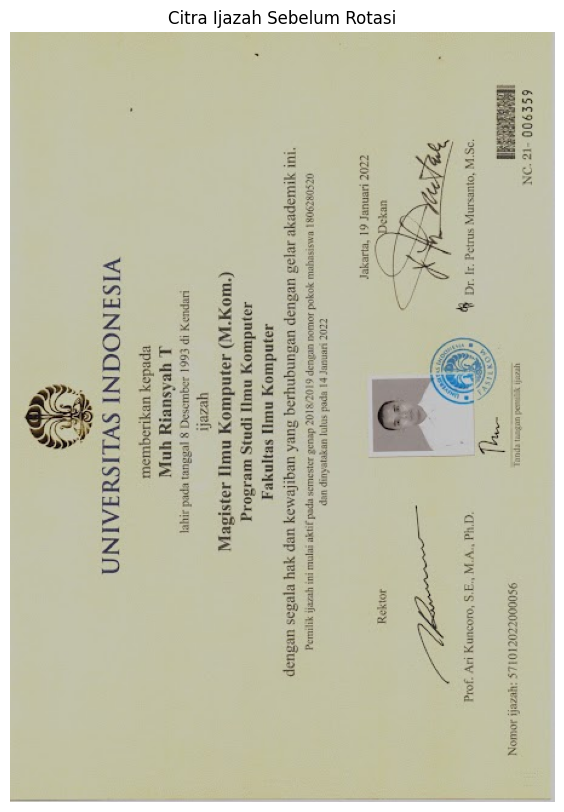

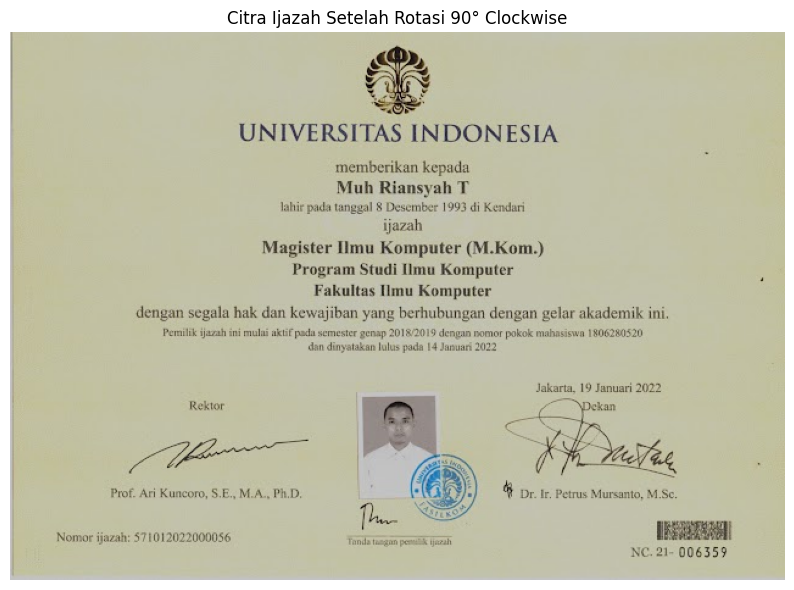

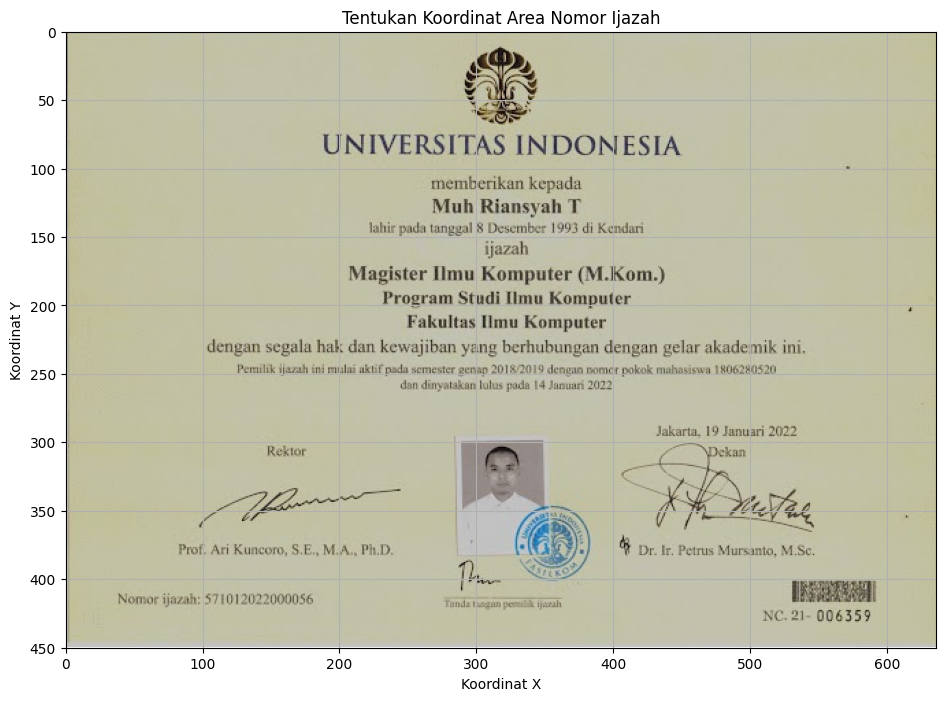

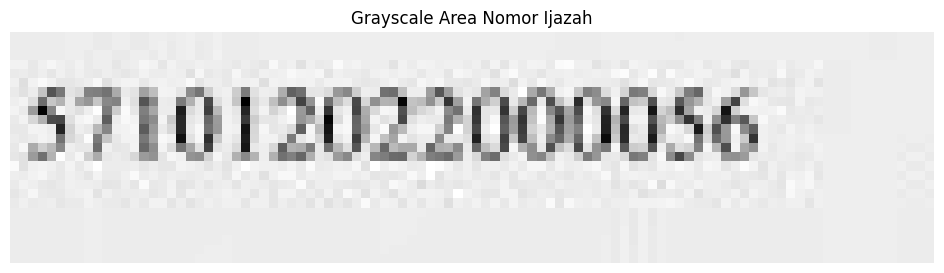

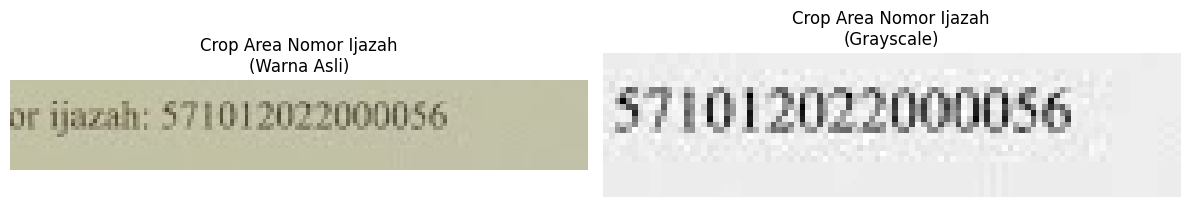

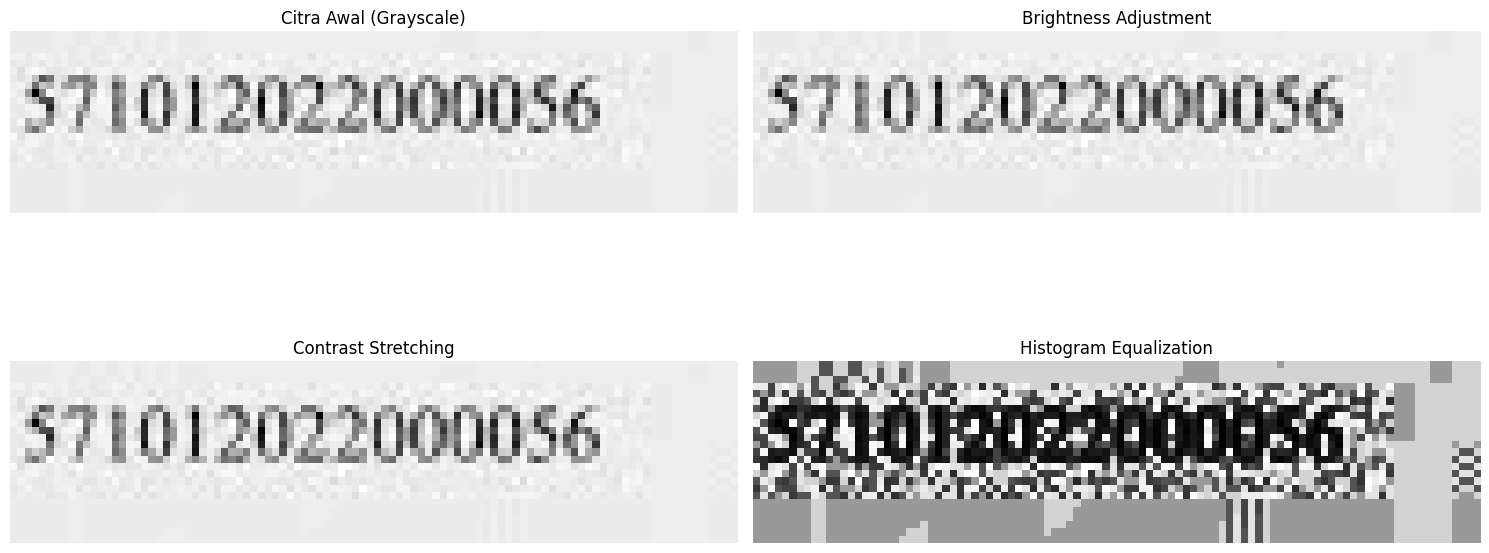

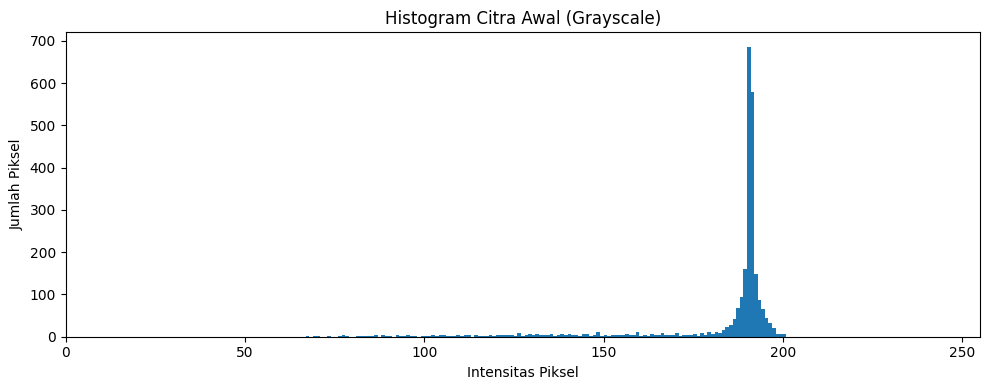

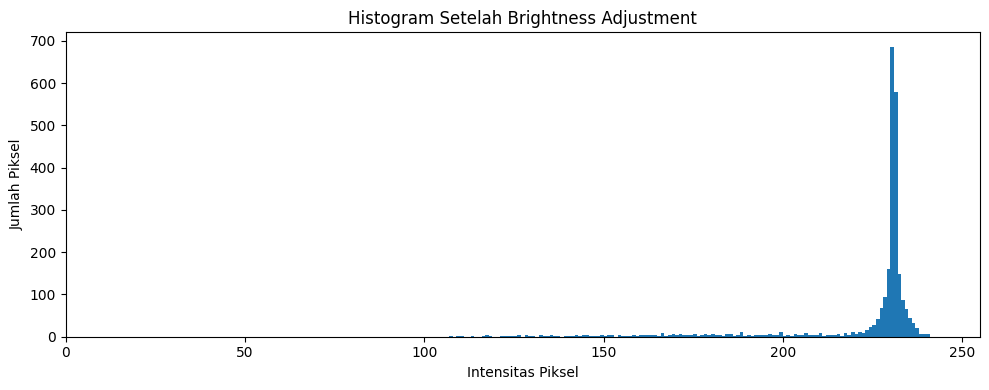

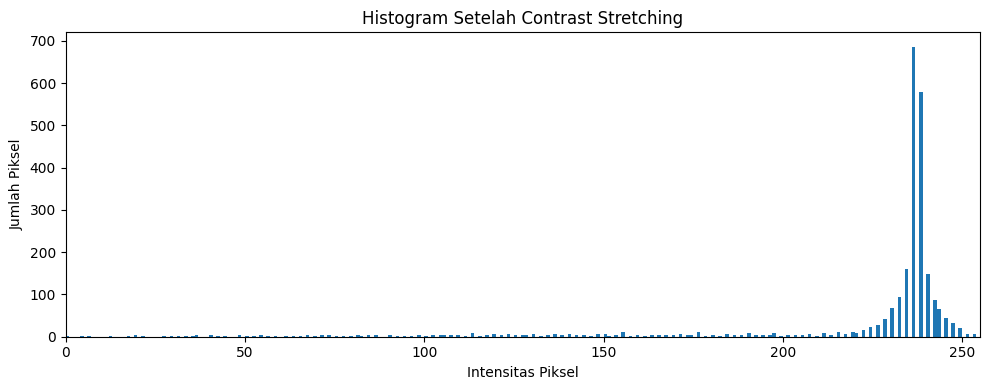

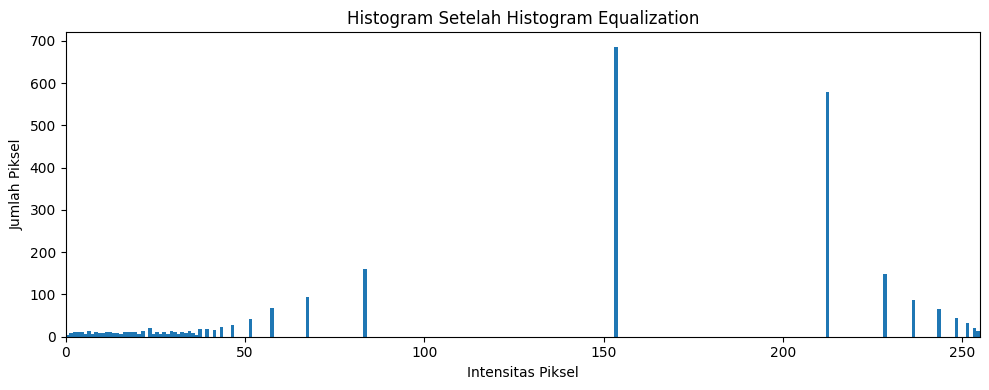

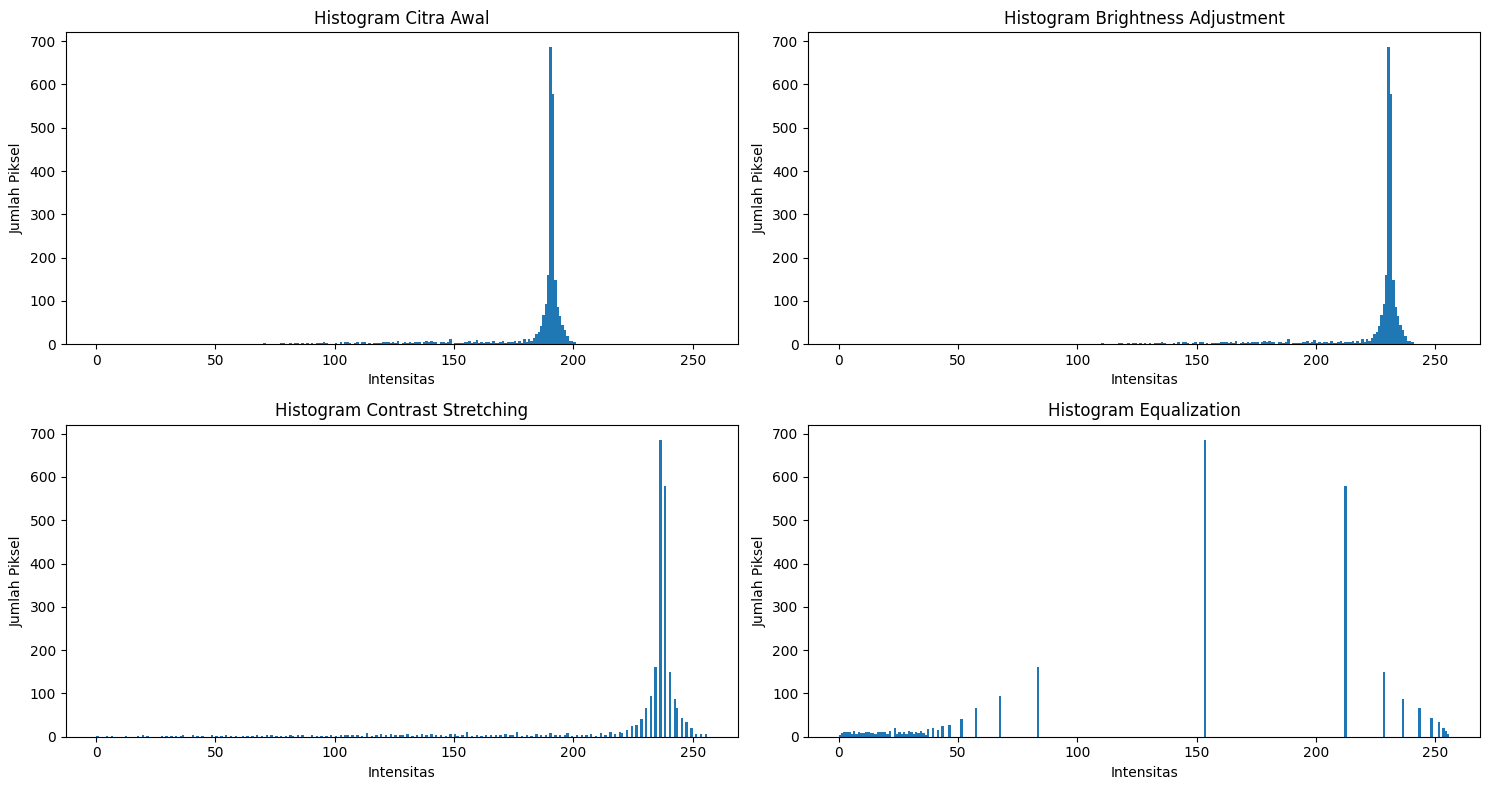


STATISTIK INTENSITAS PIXEL

1. Citra Awal (Grayscale)
   Minimum : 67
   Maksimum: 200
   Rata-rata: 182.73
   Standar Deviasi: 21.63

2. Brightness Adjustment
   Minimum : 107
   Maksimum: 240
   Rata-rata: 222.73
   Standar Deviasi: 21.63

3. Contrast Stretching
   Minimum : 0
   Maksimum: 255
   Rata-rata: 222.01
   Standar Deviasi: 41.51

4. Histogram Equalization
   Minimum : 0
   Maksimum: 255
   Rata-rata: 145.42
   Standar Deviasi: 77.96

SEMUA HASIL BERHASIL DISIMPAN!
01_grayscale_nomor.png
02_brightness.png
03_contrast_stretching.png
04_histogram_equalization.png


In [5]:
# ============================================================
# PENGOLAHAN CITRA - ENHANCEMENT AREA NOMOR IJAZAH
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. MEMBACA CITRA IJAZAH
# ============================================================

nama_file = "gambar5.jpg"

img = cv2.imread(nama_file)

if img is None:
    print("Gambar tidak ditemukan!")
    print("Pastikan nama file dan lokasinya sudah benar.")
    exit()

print("Gambar berhasil dibaca.")
print("Ukuran gambar:")
print("Tinggi :", img.shape[0])
print("Lebar  :", img.shape[1])


# ============================================================
# 2. MENAMPILKAN CITRA ASLI
# ============================================================

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 10))
plt.imshow(img_rgb)
plt.title("Citra Ijazah Sebelum Rotasi")
plt.axis("off")
plt.show()


# ============================================================
# 3. ROTASI CITRA 90 DERAJAT
# ============================================================

rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(rotated_rgb)
plt.title("Citra Ijazah Setelah Rotasi 90° Clockwise")
plt.axis("off")
plt.show()


# ============================================================
# 4. CROP AREA NOMOR IJAZAH
# ============================================================
# Format:
# rotated[y_awal:y_akhir, x_awal:x_akhir]
# ============================================================
# MENENTUKAN KOORDINAT AREA NOMOR IJAZAH
# ============================================================

crop = rotated[405:430, 100:200]
plt.figure(figsize=(12, 8))
plt.imshow(rotated_rgb)

plt.xlim(0, rotated.shape[1])
plt.ylim(rotated.shape[0], 0)

plt.xlabel("Koordinat X")
plt.ylabel("Koordinat Y")
plt.title("Tentukan Koordinat Area Nomor Ijazah")

plt.grid()

plt.show()


# ============================================================
# 5. KONVERSI CROP MENJADI GRAYSCALE
# ============================================================

gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 3))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Area Nomor Ijazah")
plt.axis("off")
plt.show()


# ============================================================
# 6. BRIGHTNESS ADJUSTMENT
# ============================================================
# alpha = 1.0  -> tidak mengubah kontras
# beta  = 40   -> menambah kecerahan sebesar 40

brightness = cv2.convertScaleAbs(
    gray,
    alpha=1.0,
    beta=40
)


# ============================================================
# 7. CONTRAST STRETCHING
# ============================================================
# Intensitas minimum dipetakan menjadi 0
# Intensitas maksimum dipetakan menjadi 255

contrast_stretch = cv2.normalize(
    gray,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)


# ============================================================
# 8. HISTOGRAM EQUALIZATION
# ============================================================

hist_equalization = cv2.equalizeHist(gray)


# ============================================================
# 9. PERBANDINGAN CITRA ASLI DAN GRAYSCALE
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(crop_rgb)
plt.title("Crop Area Nomor Ijazah\n(Warna Asli)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Crop Area Nomor Ijazah\n(Grayscale)")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 10. PERBANDINGAN 3 METODE ENHANCEMENT
# ============================================================

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Citra Awal (Grayscale)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(brightness, cmap="gray")
plt.title("Brightness Adjustment")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(contrast_stretch, cmap="gray")
plt.title("Contrast Stretching")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(hist_equalization, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 11. HISTOGRAM CITRA AWAL
# ============================================================

plt.figure(figsize=(10, 4))

plt.hist(
    gray.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram Citra Awal (Grayscale)")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()


# ============================================================
# 12. HISTOGRAM BRIGHTNESS ADJUSTMENT
# ============================================================

plt.figure(figsize=(10, 4))

plt.hist(
    brightness.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram Setelah Brightness Adjustment")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()


# ============================================================
# 13. HISTOGRAM CONTRAST STRETCHING
# ============================================================

plt.figure(figsize=(10, 4))

plt.hist(
    contrast_stretch.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram Setelah Contrast Stretching")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()


# ============================================================
# 14. HISTOGRAM EQUALIZATION
# ============================================================

plt.figure(figsize=(10, 4))

plt.hist(
    hist_equalization.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram Setelah Histogram Equalization")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 255])

plt.tight_layout()
plt.show()


# ============================================================
# 15. PERBANDINGAN SEMUA HISTOGRAM
# ============================================================

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title("Histogram Citra Awal")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 2, 2)
plt.hist(brightness.ravel(), bins=256, range=[0, 256])
plt.title("Histogram Brightness Adjustment")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 2, 3)
plt.hist(contrast_stretch.ravel(), bins=256, range=[0, 256])
plt.title("Histogram Contrast Stretching")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(2, 2, 4)
plt.hist(hist_equalization.ravel(), bins=256, range=[0, 256])
plt.title("Histogram Equalization")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()


# ============================================================
# 16. STATISTIK INTENSITAS PIXEL
# ============================================================

print("\n==============================================")
print("STATISTIK INTENSITAS PIXEL")
print("==============================================")

print("\n1. Citra Awal (Grayscale)")
print("   Minimum :", gray.min())
print("   Maksimum:", gray.max())
print("   Rata-rata:", round(gray.mean(), 2))
print("   Standar Deviasi:", round(gray.std(), 2))

print("\n2. Brightness Adjustment")
print("   Minimum :", brightness.min())
print("   Maksimum:", brightness.max())
print("   Rata-rata:", round(brightness.mean(), 2))
print("   Standar Deviasi:", round(brightness.std(), 2))

print("\n3. Contrast Stretching")
print("   Minimum :", contrast_stretch.min())
print("   Maksimum:", contrast_stretch.max())
print("   Rata-rata:", round(contrast_stretch.mean(), 2))
print("   Standar Deviasi:", round(contrast_stretch.std(), 2))

print("\n4. Histogram Equalization")
print("   Minimum :", hist_equalization.min())
print("   Maksimum:", hist_equalization.max())
print("   Rata-rata:", round(hist_equalization.mean(), 2))
print("   Standar Deviasi:", round(hist_equalization.std(), 2))


# ============================================================
# 17. MENYIMPAN HASIL ENHANCEMENT
# ============================================================

cv2.imwrite(
    "01_grayscale_nomor.png",
    gray
)

cv2.imwrite(
    "02_brightness.png",
    brightness
)

cv2.imwrite(
    "03_contrast_stretching.png",
    contrast_stretch
)

cv2.imwrite(
    "04_histogram_equalization.png",
    hist_equalization
)

print("\n==============================================")
print("SEMUA HASIL BERHASIL DISIMPAN!")
print("==============================================")

print("01_grayscale_nomor.png")
print("02_brightness.png")
print("03_contrast_stretching.png")
print("04_histogram_equalization.png")